# Analyzing Sperm Whale Codas with VAD V2
Sperm whales communicate with each other through making clicks, and combining these into patterns called codas. A sperm whale coda is 3-40 clicks grouped together usually lasting for less than 2 seconds, and separated from the next coda by a silence of at least a second. Different coda's differ in the number of clicks, the spacing between the clicks. The sperm whales of the Eastern Caribbean clan have at least 18 codas, but these codas are further modified in various ways such as varying the tempo. The most common coda the Eastern Caribbean clan makes is the 1+1+3, which is thought to be the clan membership name. That's the coda made in this file by 2 whales, who sometimes overlap

Goal: Use Voice Activity Detection (VAD) to separate the file into individual codas, then use VAD to gather metadata on each coda that could be used to transcribe them, including the number of clicks per coda the total coda duration and the inter-click durations. 

Input: file.wav
Output: 
Array where each object is a coda metadata in this format:
```
[
    {
        start: number, // start time for the coda in the file
        end: number, // end time for the coda in the file
        number_of_clicks: number, // total number of clicks in the coda
        duration: number, // total duration of the whole coda in ms
        durations_of_interclick_intervals: number[], // duration of each ICI in ms
        content: '1+1+3' | '', // label for coda, if identified
        vad: number[], // raw VAD output which was used to identify individual clicks in each coda
        click_timestamps: [ // timestamps for the start/end of each click
            {
                start: number,
                end: number,
            }
        ],
        silence_timestamps: [ // timestamps for the start/end of each silence between the clicks
            {
                start: number,
                end: number,
            }
        ],
    }
]
```

Audio from [Dominica Sperm Whale Project](https://www.thespermwhaleproject.org/) and [Project CETI](https://www.projectceti.org/)
 - [1-1-3-exchange-2-whales.WAV](https://soundcloud.com/user-152468598/1-1-3-exchange-2-whales)
 - [5R Exchange 2 Whales Diving](https://soundcloud.com/user-152468598/5r-exchange-2-whales-diving)
 - [Communication](https://soundcloud.com/user-152468598/communication)
 - [CommunicationSHORT](https://soundcloud.com/user-152468598/communicationshort?in=user-152468598/sets/sperm-whale-vocalizations)
 - [Longer social sequence](https://soundcloud.com/user-152468598/longer-social-sequence?in=user-152468598/sets/sperm-whale-vocalizations)
 - [Social Exchange Unit R](https://soundcloud.com/user-152468598/social-exchange-unit-r?in=user-152468598/sets/sperm-whale-vocalizations)
 - [Talk Codas](https://soundcloud.com/user-152468598/talk-codas?in=user-152468598/sets/sperm-whale-vocalizations)

Date last updated: 6/15/2025 Author: Kay Rubio

In [1]:
import librosa
import librosa.display
from vad import EnergyVAD # https://pypi.org/project/energy-vad/
from typing import List
import matplotlib.pyplot as plt

## Helper Methods

In [2]:
# Function to plot a waveform with title and optional section highlights based on timestamps
def plotWaveform(audio, title, sections=[], sections2=[]):
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(audio, sr=sr, alpha=0.5, color='blue')
    plt.title(title)
    plt.xlabel("Time (sec)") 
    plt.ylabel("Amplitude")
    for section in sections:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='purple', alpha=0.3)
    for section in sections2:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='yellow', alpha=0.3)
    plt.show()

In [3]:
# Function that takes in
#  - vad_output as a List of 0's and 1's, where 0 = frame with silence and 1 = voice activity
#  - frame_shift in ms
#  - min_silence_duration, which is the minimum time of silence in ms that separates a group of sound
# Returns periods of time with voice activity separated by silences longer than the min_silence_duration
# Output format: [{'start': number, 'end': number}]
def get_voice_activity_timestamps(*, vad_output: List[int], frame_shift: int, min_silence_duration: int = 1000):
    min_silence_frames = int(min_silence_duration / frame_shift)

    groups = []
    start_idx = None
    silence_counter = 0

    for i, frame in enumerate(vad_output):
        if frame == 1:
            if start_idx is None:
                start_idx = i
            silence_counter = 0
        else:
            if start_idx is not None:
                silence_counter += 1
                if silence_counter >= min_silence_frames:
                    # Silence is long enough, so close the current voice group
                    end_idx = i - silence_counter
                    start_time = start_idx * frame_shift / 1000
                    end_time = (end_idx + 1) * frame_shift / 1000
                    groups.append({
                        'start': round(start_time, 4),
                        'end': round(end_time, 4)
                    })
                    start_idx = None
                    silence_counter = 0

    # Handle case where audio ends with voice activity
    if start_idx is not None:
        end_time = (len(vad_output)+1) * frame_shift / 1000
        groups.append({
            'start': round(start_idx * frame_shift / 1000, 4),
            'end': round(end_time, 4)
        })

    return groups

In [4]:
# Function that takes in
#  - vad_output as a List of 0's and 1's, where 0 = frame with silence and 1 = voice activity
#  - frame_shift in ms
#  - min_silence_duration, which is the minimum time of silence in ms that will be included
# Returns timestamps for silences longer than the min_silence_duration
# Output format: [{'start': number, 'end': number}]
def get_timestamps_silences(*, vad_output: List[int], frame_shift: int, min_silence_duration: int=1000):
    min_silence_frames = int(min_silence_duration / frame_shift)
    groups = []
    start_idx = None

    for i, frame in enumerate(vad_output):
        if frame==0:
            if start_idx is None:
                start_idx = i-1
        else:
            if start_idx is not None:
                end_idx = i
                duration = end_idx - (start_idx + 1)

                if duration >= min_silence_frames:
                    start_time = (start_idx + 1) * frame_shift / 1000
                    end_time = end_idx * frame_shift / 1000
                    groups.append({
                        'start': round(start_time, 2),
                        'end': round(end_time, 2)
                    })

                start_idx = None

    # Handle case where the last segment goes to the end
    if start_idx is not None:
        end_idx = len(vad_output)
        duration = (end_idx - 1) - (start_idx + 1)
        if duration >= min_silence_frames:
            start_time = (start_idx + 1) * frame_shift / 1000
            end_time = end_idx * frame_shift / 1000
            groups.append({
                'start': round(start_time, 2),
                'end': round(end_time, 2)
            })

    return groups

In [5]:
# Function to spit an audio into an array of individual audios by timestamp.
# Assumes timestamps are in format {'start': time in seconds, 'end': time in seconds}
def splitAudioByTimestamps(audio, timestamps, sr):
    audio_array = []
    for i, ts in enumerate(timestamps):
        start_sample = int(float(ts['start']) * sr) # convert start time into sample index
        end_sample = int(float(ts['end']) * sr)
        segment = audio[start_sample:end_sample] # Extract the segment using start and ending sample index
        audio_array.append(segment) # append segment into the array
    return audio_array

In [6]:
# Convert timestamps into durations
# Returns timestamps in format {'start': time in seconds, 'end': time in seconds}
def convert_timestamps_to_durations(timestamps):
    durations = []
    for i, timestamps in enumerate(timestamps):
        durations.append(round(float(timestamps['end'])-float(timestamps['start']), 4))
    return durations

## Exploring Files

In [25]:
FRAME_LENGTH = 25 # milliseconds
FRAME_SHIFT = 10 # milliseconds

# NOTE: EnergyVAD takes in different sampling rates but seems to work
# best and avoid drift with 16000 rather than Librosa default of 22050
sr = 16000

# Generally a silence longer than a second is should separate one coda from another
MIN_SILENCE_BETWEEN_CODAS = 1000 # in milliseconds
MIN_SILENCE_BETWEEN_CLICKS = 10 # in milliseconds

# Initialize VAD and get the output, which is an array of 0's and 1's, where 0 = frame with silence
# and 1 = frame with voice activity above the energy threshold
vad = EnergyVAD(frame_length=FRAME_LENGTH, frame_shift=FRAME_SHIFT, sample_rate=sr, energy_threshold=0.5)

In [26]:
#filename = '1_1_3_exchange_2_whales.wav'
filename = '5r_exchange_2_whales_diving.wav'
# filename = 'longer_social_sequence.wav'
# filename = 'social_exchange_unit_r.wav'

# less helpful due to a lot of coda overlap
# filename = 'communication_short.wav'
# filename = 'communication.wav'
# filename = 'talk_codas.wav'

In [27]:
# Load audio with Librosa.load and resample
file, sr = librosa.load(filename, sr=sr)

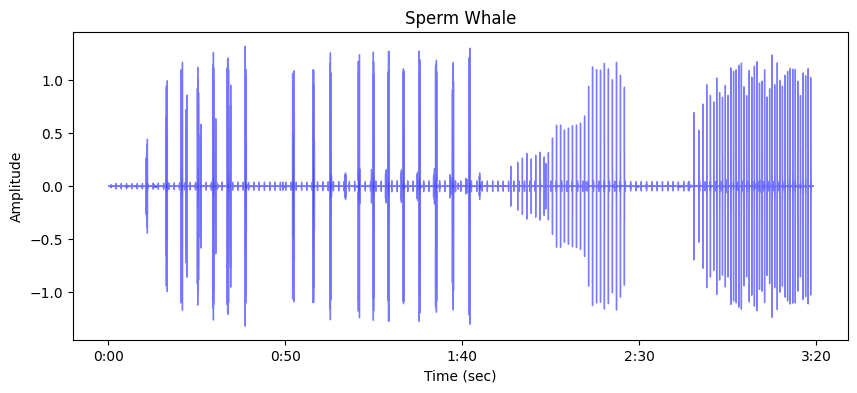

In [28]:
plotWaveform(file, 'Sperm Whale')

In [29]:
vad_output = vad(file)

In [12]:
# Get timestamps for codas
codas = get_voice_activity_timestamps(vad_output=vad_output, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_SILENCE_BETWEEN_CODAS)
codas

[{'start': 10.61, 'end': 10.97},
 {'start': 16.17, 'end': 16.59},
 {'start': 20.47, 'end': 22.14},
 {'start': 25.05, 'end': 26.17},
 {'start': 29.37, 'end': 30.28},
 {'start': 33.49, 'end': 34.51},
 {'start': 38.53, 'end': 38.91},
 {'start': 51.93, 'end': 52.47},
 {'start': 57.65, 'end': 58.13},
 {'start': 62.52, 'end': 62.96},
 {'start': 66.67, 'end': 66.93},
 {'start': 70.51, 'end': 70.92},
 {'start': 74.24, 'end': 75.02},
 {'start': 78.21, 'end': 79.22},
 {'start': 82.6, 'end': 83.51},
 {'start': 87.11, 'end': 88.03},
 {'start': 92.04, 'end': 92.68},
 {'start': 97.09, 'end': 97.44},
 {'start': 101.8, 'end': 102.15},
 {'start': 118.12, 'end': 118.14},
 {'start': 120.64, 'end': 120.66},
 {'start': 121.84, 'end': 121.86},
 {'start': 123.03, 'end': 123.05},
 {'start': 124.21, 'end': 124.23},
 {'start': 125.36, 'end': 125.38},
 {'start': 126.51, 'end': 126.54},
 {'start': 127.64, 'end': 127.66},
 {'start': 128.75, 'end': 128.77},
 {'start': 129.88, 'end': 129.91},
 {'start': 131.02, 'end

In [13]:
len(codas)

48

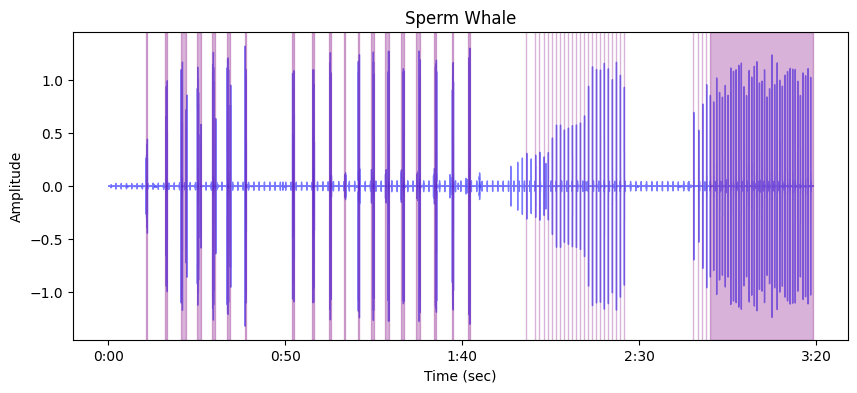

In [14]:
plotWaveform(file, 'Sperm Whale', codas)

In [15]:
# Get timestamps for silences between codas
inter_coda_silences = get_timestamps_silences(vad_output=vad_output, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_SILENCE_BETWEEN_CODAS)
inter_coda_silences

[{'start': 0.0, 'end': 10.61},
 {'start': 10.97, 'end': 16.17},
 {'start': 16.59, 'end': 20.47},
 {'start': 22.14, 'end': 25.05},
 {'start': 26.17, 'end': 29.37},
 {'start': 30.28, 'end': 33.49},
 {'start': 34.51, 'end': 38.53},
 {'start': 38.91, 'end': 51.93},
 {'start': 52.47, 'end': 57.65},
 {'start': 58.13, 'end': 62.52},
 {'start': 62.96, 'end': 66.67},
 {'start': 66.93, 'end': 70.51},
 {'start': 70.92, 'end': 74.24},
 {'start': 75.02, 'end': 78.21},
 {'start': 79.22, 'end': 82.6},
 {'start': 83.51, 'end': 87.11},
 {'start': 88.03, 'end': 92.04},
 {'start': 92.68, 'end': 97.09},
 {'start': 97.44, 'end': 101.8},
 {'start': 102.15, 'end': 118.12},
 {'start': 118.14, 'end': 120.64},
 {'start': 120.66, 'end': 121.84},
 {'start': 121.86, 'end': 123.03},
 {'start': 123.05, 'end': 124.21},
 {'start': 124.23, 'end': 125.36},
 {'start': 125.38, 'end': 126.51},
 {'start': 126.54, 'end': 127.64},
 {'start': 127.66, 'end': 128.75},
 {'start': 128.77, 'end': 129.88},
 {'start': 129.91, 'end': 

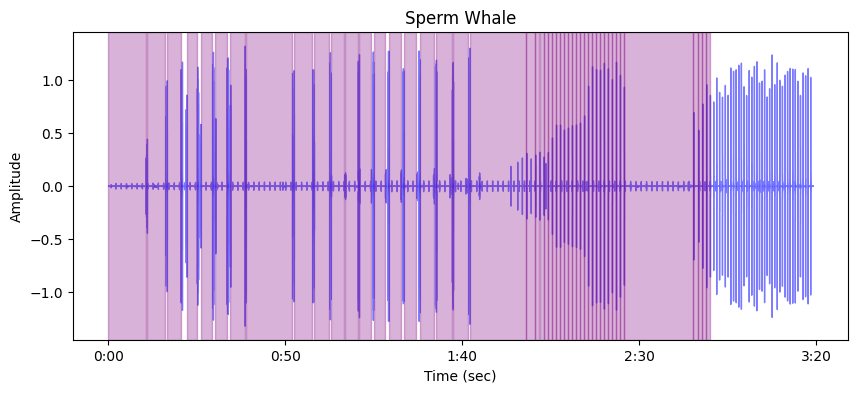

In [16]:
plotWaveform(file, 'Sperm Whale', inter_coda_silences)

In [17]:
# Get timestamps for individual clicks

In [18]:
clicks = get_voice_activity_timestamps(vad_output=vad_output, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_SILENCE_BETWEEN_CLICKS)
clicks

[{'start': 10.61, 'end': 10.64},
 {'start': 10.69, 'end': 10.72},
 {'start': 10.79, 'end': 10.81},
 {'start': 10.86, 'end': 10.89},
 {'start': 10.94, 'end': 10.97},
 {'start': 16.17, 'end': 16.2},
 {'start': 16.29, 'end': 16.32},
 {'start': 16.39, 'end': 16.42},
 {'start': 16.46, 'end': 16.5},
 {'start': 16.56, 'end': 16.59},
 {'start': 20.47, 'end': 20.5},
 {'start': 20.58, 'end': 20.61},
 {'start': 20.68, 'end': 20.71},
 {'start': 20.75, 'end': 20.79},
 {'start': 20.84, 'end': 20.88},
 {'start': 21.8, 'end': 21.83},
 {'start': 21.87, 'end': 21.91},
 {'start': 21.96, 'end': 21.99},
 {'start': 22.03, 'end': 22.07},
 {'start': 22.1, 'end': 22.14},
 {'start': 25.05, 'end': 25.09},
 {'start': 25.15, 'end': 25.19},
 {'start': 25.24, 'end': 25.28},
 {'start': 25.32, 'end': 25.36},
 {'start': 25.39, 'end': 25.42},
 {'start': 25.83, 'end': 25.86},
 {'start': 25.91, 'end': 25.94},
 {'start': 26.0, 'end': 26.02},
 {'start': 26.07, 'end': 26.1},
 {'start': 26.14, 'end': 26.17},
 {'start': 29.37,

In [19]:
len(clicks)

208

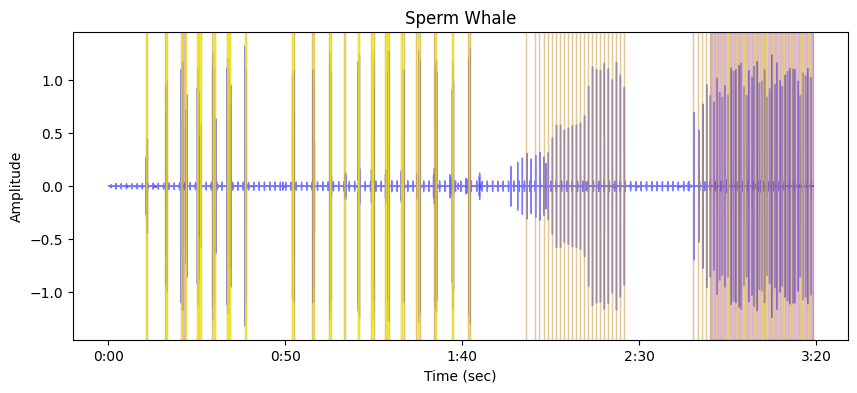

In [20]:
plotWaveform(file, 'Sperm Whale', codas, clicks)

In [21]:
# Take original audio, split into an array of files, one for each coda and trim off silence at beginning and end
coda_audios = splitAudioByTimestamps(file, codas, sr)

In [22]:
# Examine a coda in detail

In [23]:
# get vad_output for the coda
coda = coda_audios[19]
vad_output_for_coda = vad(coda)

# Get the timestamps for clicks inside each coda
coda_clicks = get_voice_activity_timestamps(vad_output=vad_output_for_coda, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_SILENCE_BETWEEN_CLICKS)
coda_clicks

[]

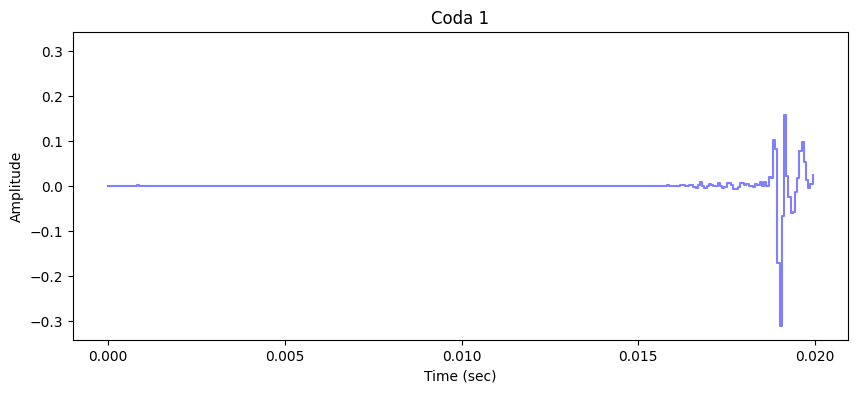

In [24]:
plotWaveform(coda, 'Coda 1', coda_clicks)

In [239]:
# Get the timestamps for inter-click-silences inside each coda
inter_click_silences = get_timestamps_silences(vad_output=vad_output_for_coda, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_SILENCE_BETWEEN_CLICKS)
inter_click_silences

[{'start': 0.05, 'end': 0.41},
 {'start': 0.46, 'end': 0.82},
 {'start': 0.86, 'end': 1.04},
 {'start': 1.09, 'end': 1.24}]

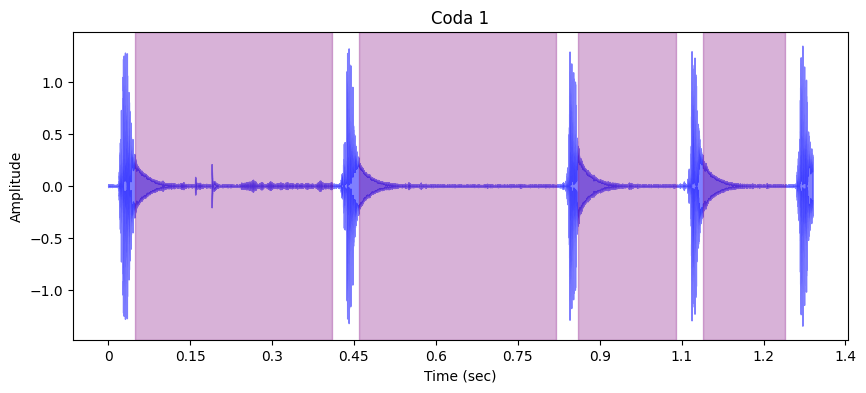

In [240]:
plotWaveform(coda, 'Coda 1', inter_click_silences)

In [243]:
# for each coda in coda_timestamps, look at the audio in coda_audio that is in the same position
# in the array and extract features about it, then save that info to coda_timestamps object
for i, coda_audio in enumerate(coda_audios):
    # get vad_output for each coda
    vad_output_for_coda = vad(coda_audio)
    # codas[i]['vad'] = vad_output_for_coda

    # Get the timestamps for clicks inside each coda
    clicks = get_voice_activity_timestamps(vad_output=vad_output_for_coda, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_SILENCE_BETWEEN_CLICKS)
    codas[i]['click_timestamps'] = clicks
    
    # Use timestamps of the clicks to find the total number of clicks
    number_of_clicks = len(clicks)
    codas[i]['number_of_clicks'] = number_of_clicks

    # Use timestamps of the clicks to find total duration of the coda (time from beginning of first click
    # to end of last click)
    duration = 0
    if number_of_clicks > 0:
          duration = float(clicks[len(clicks)-1]['end']) - float(clicks[0]['start'])
    codas[i]['duration'] = duration

    # Use VAD output to extract timestamps of the silences

    inter_click_silences = get_timestamps_silences(vad_output=vad_output_for_coda, frame_shift=FRAME_SHIFT, min_silence_duration=MIN_SILENCE_BETWEEN_CLICKS)
    codas[i]['silence_timestamps'] = inter_click_silences

    # Get the inter-click-interval durations in seconds
    durations_of_interclick_intervals = convert_timestamps_to_durations(inter_click_silences)
    codas[i]['durations_of_interclick_intervals'] = durations_of_interclick_intervals

    # Check if the coda conforms to 1+1+3 using a simple formula
    if number_of_clicks == 5 and durations_of_interclick_intervals[0] > 0.23 and durations_of_interclick_intervals[1] > 0.25 and durations_of_interclick_intervals[2] <= 0.2 and durations_of_interclick_intervals[3] <= 0.2:
        codas[i]['content'] = '1+1+3'
    else: 
        codas[i]['content'] = ''

codas

[{'start': 1.8,
  'end': 3.08,
  'number_of_clicks': 5,
  'durations_of_interclick_intervals': [0.4, 0.38, 0.16, 0.17],
  'content': '1+1+3',
  'silence_timestamps': [{'start': 0.04, 'end': 0.44},
   {'start': 0.47, 'end': 0.85},
   {'start': 0.89, 'end': 1.05},
   {'start': 1.08, 'end': 1.25}],
  'click_timestamps': [{'start': 0.0, 'end': 0.04},
   {'start': 0.44, 'end': 0.47},
   {'start': 0.85, 'end': 0.89},
   {'start': 1.05, 'end': 1.08},
   {'start': 1.25, 'end': 1.27}],
  'duration': 1.27},
 {'start': 7.49,
  'end': 8.48,
  'number_of_clicks': 5,
  'durations_of_interclick_intervals': [0.27, 0.24, 0.11, 0.12],
  'content': '',
  'silence_timestamps': [{'start': 0.05, 'end': 0.32},
   {'start': 0.37, 'end': 0.61},
   {'start': 0.66, 'end': 0.77},
   {'start': 0.82, 'end': 0.94}],
  'click_timestamps': [{'start': 0.0, 'end': 0.05},
   {'start': 0.32, 'end': 0.37},
   {'start': 0.61, 'end': 0.66},
   {'start': 0.77, 'end': 0.82},
   {'start': 0.94, 'end': 0.98}],
  'duration': 0.98